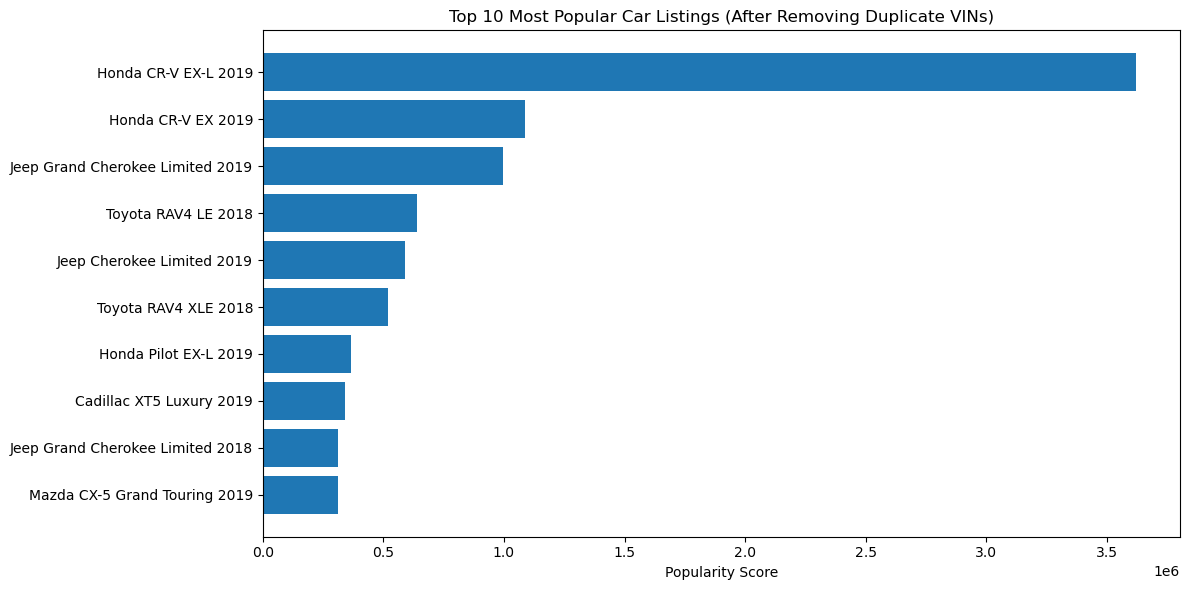

In [46]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('Online_Cars_Sale_Marketplace.csv')

# Remove duplicate VINs (keep first occurrence)
if 'VIN' in df.columns:
    df = df.drop_duplicates(subset='VIN', keep='first')

# Fill missing consumer reviews and ratings with 0
df[['ConsumerReviews', 'ConsumerRating']] = df[['ConsumerReviews', 'ConsumerRating']].fillna(0)

# Define how to group cars (Make, Model, Year)
group_cols = ['Make', 'Model', 'Year']

# Group the data
car_summary = df.groupby(group_cols).agg({
    'ConsumerReviews': 'sum',
    'ConsumerRating': 'mean'
}).reset_index()

# Add number of listings
car_summary['Num_Listings'] = df.groupby(group_cols).size().values

# Add square root of number of listings
car_summary['Sqrt_Listings'] = np.sqrt(car_summary['Num_Listings'])

# Calculate the Popularity Score
car_summary['Popularity_Score'] = (
    car_summary['ConsumerReviews'] *
    car_summary['ConsumerRating'] *
    car_summary['Sqrt_Listings']
)

# Sort by popularity score and get top 10
top_cars = car_summary.sort_values(by='Popularity_Score', ascending=False).head(10)


# (Optional) Plot the results
plt.figure(figsize=(12,6))
plt.barh(top_cars['Make'] + ' ' + top_cars['Model'] + ' ' + top_cars['Year'].astype(str), top_cars['Popularity_Score'])
plt.xlabel('Popularity Score')
plt.title('Top 10 Most Popular Car Listings (After Removing Duplicate VINs)')
plt.gca().invert_yaxis()  # Highest on top
plt.tight_layout()
plt.show()


<>:13: SyntaxWarning: invalid escape sequence '\$'
<>:13: SyntaxWarning: invalid escape sequence '\$'
C:\Users\patron\AppData\Local\Temp\ipykernel_32192\1224089890.py:13: SyntaxWarning: invalid escape sequence '\$'
  .replace({'\$': '', ',': ''}, regex=True)


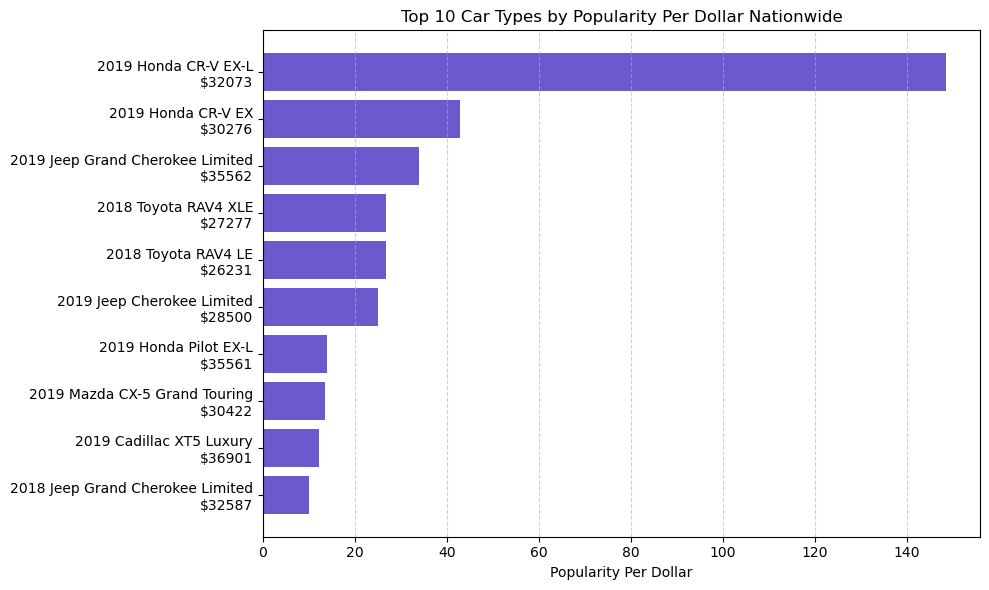

In [48]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
file_path = 'Online_Cars_Sale_Marketplace.csv'
df = pd.read_csv(file_path)

# Step 1: Clean the 'Price' column
df['Price'] = (
    df['Price']
    .replace({'\$': '', ',': ''}, regex=True)
    .replace('Not Priced', np.nan)
)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Step 2: Group by Year, Make, Model and compute aggregates
grouped_nationwide = df.groupby(['Year', 'Make', 'Model']).agg({
    'ConsumerRating': 'mean',
    'ConsumerReviews': 'sum',
    'Price': 'mean',
    'VIN': 'count'
}).reset_index()

# Step 3: Compute scores
grouped_nationwide = grouped_nationwide.rename(columns={'VIN': 'Listings'})
grouped_nationwide['SqrtListings'] = np.sqrt(grouped_nationwide['Listings'])
grouped_nationwide['SqrtAdjustedPopularity'] = (
    grouped_nationwide['ConsumerRating'] *
    grouped_nationwide['ConsumerReviews'] *
    grouped_nationwide['SqrtListings']
)
grouped_nationwide['PopularityPerDollar'] = (
    grouped_nationwide['SqrtAdjustedPopularity'] / grouped_nationwide['Price']
)

# Step 4: Remove invalid rows
filtered_nationwide = grouped_nationwide.dropna(subset=['PopularityPerDollar'])
filtered_nationwide = filtered_nationwide[
    filtered_nationwide['PopularityPerDollar'].replace([np.inf, -np.inf], np.nan).notnull()
]

# Step 5: Select top 10 value cars
top10_value_nationwide = filtered_nationwide.sort_values(
    by='PopularityPerDollar', ascending=False
).head(10).copy()

# Step 6: Create readable labels
top10_value_nationwide['CarLabel'] = (
    top10_value_nationwide['Year'].astype(str) + ' ' +
    top10_value_nationwide['Make'] + ' ' +
    top10_value_nationwide['Model']
)
top10_value_nationwide['BarLabel'] = (
    top10_value_nationwide['CarLabel'] + '\n$' +
    top10_value_nationwide['Price'].round(0).astype(int).astype(str)
)

# Step 7: Plot
plt.figure(figsize=(10, 6))
plt.barh(top10_value_nationwide['BarLabel'], top10_value_nationwide['PopularityPerDollar'], color='slateblue')
plt.gca().invert_yaxis()
plt.xlabel('Popularity Per Dollar')
plt.title('Top 10 Car Types by Popularity Per Dollar Nationwide')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


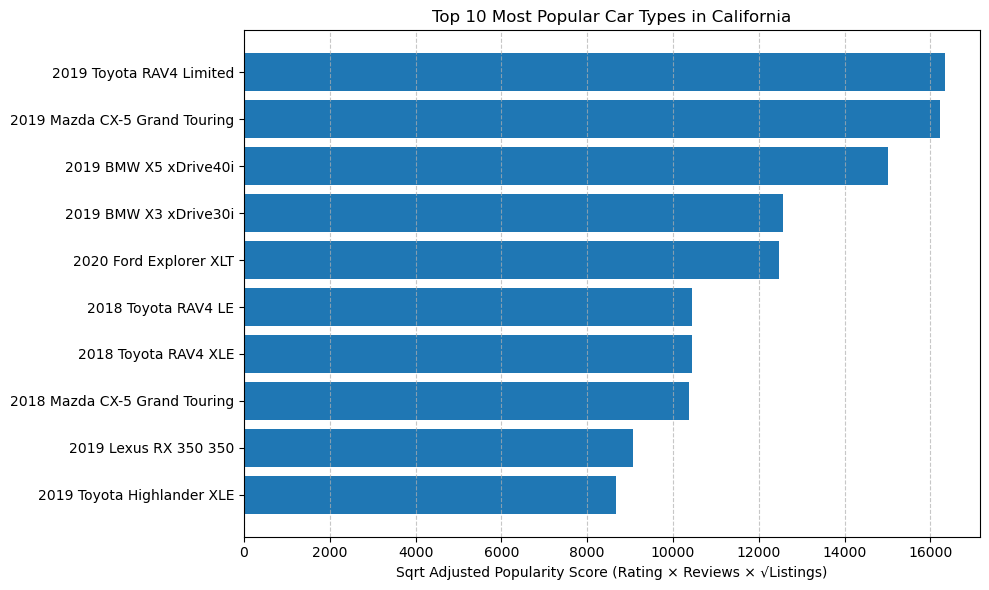

In [74]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load the data
file_path = 'Online_Cars_Sale_Marketplace.csv'
df = pd.read_csv(file_path)

# Step 2: Filter for California
df_ca = df[df['State'] == 'CA']

# Step 3: Group by Year, Make, Model within California
grouped_ca = df_ca.groupby(['Year', 'Make', 'Model']).agg({
    'ConsumerRating': 'mean',        # average rating
    'ConsumerReviews': 'sum',        # total reviews
    'VIN': 'count'                   # number of listings
}).reset_index()

# Step 4: Rename VIN to Listings
grouped_ca = grouped_ca.rename(columns={'VIN': 'Listings'})

# Step 5: Calculate Sqrt Adjusted Popularity Score
grouped_ca['SqrtListings'] = np.sqrt(grouped_ca['Listings'])
grouped_ca['SqrtAdjustedPopularity'] = (
    grouped_ca['ConsumerRating'] * 
    grouped_ca['ConsumerReviews'] * 
    grouped_ca['SqrtListings']
)

# Step 6: Sort and select Top 10
top10_ca = grouped_ca.sort_values(by='SqrtAdjustedPopularity', ascending=False).head(10).copy()

# Step 7: Create a readable car label
top10_ca['CarLabel'] = (
    top10_ca['Year'].astype(str) + ' ' + 
    top10_ca['Make'] + ' ' + 
    top10_ca['Model']
)

# Step 8: Plot the results
plt.figure(figsize=(10,6))
plt.barh(top10_ca['CarLabel'], top10_ca['SqrtAdjustedPopularity'])
plt.gca().invert_yaxis()
plt.xlabel('Sqrt Adjusted Popularity Score (Rating × Reviews × √Listings)')
plt.title('Top 10 Most Popular Car Types in California')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()




<>:16: SyntaxWarning: invalid escape sequence '\$'
<>:16: SyntaxWarning: invalid escape sequence '\$'
C:\Users\patron\AppData\Local\Temp\ipykernel_32192\1921900284.py:16: SyntaxWarning: invalid escape sequence '\$'
  .replace({'\$': '', ',': ''}, regex=True)


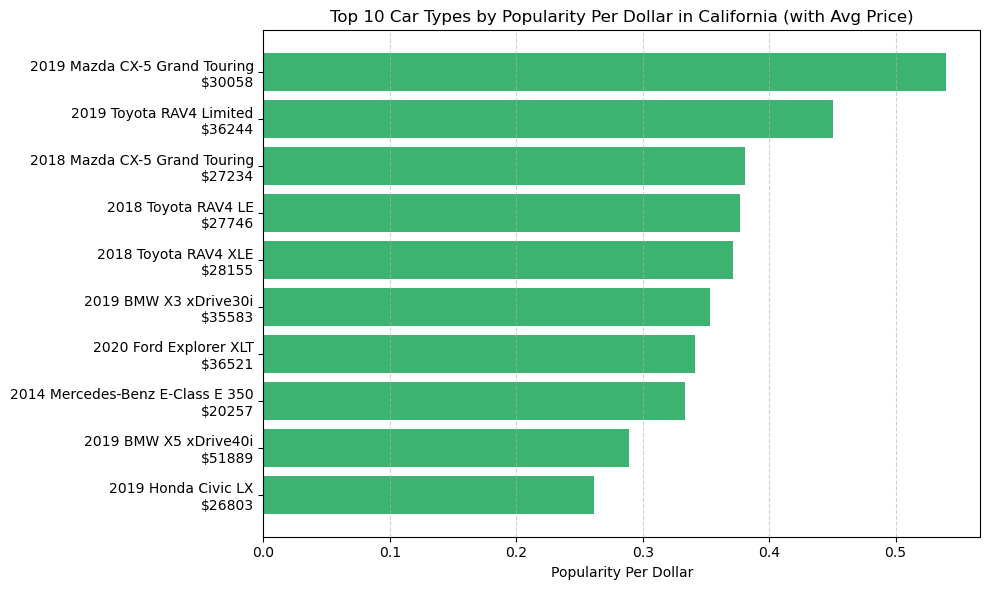

In [54]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
file_path = 'Online_Cars_Sale_Marketplace.csv'
df = pd.read_csv(file_path)

# Filter for California
df_ca = df[df['State'] == 'CA'].copy()

# Clean the 'Price' column
df_ca['Price'] = (
    df_ca['Price']
    .replace({'\$': '', ',': ''}, regex=True)
    .replace('Not Priced', np.nan)
)
df_ca['Price'] = pd.to_numeric(df_ca['Price'], errors='coerce')

# Group by car type and compute metrics
grouped_ca_value = df_ca.groupby(['Year', 'Make', 'Model']).agg({
    'ConsumerRating': 'mean',
    'ConsumerReviews': 'sum',
    'Price': 'mean',
    'VIN': 'count'
}).reset_index()

# Compute scores
grouped_ca_value = grouped_ca_value.rename(columns={'VIN': 'Listings'})
grouped_ca_value['SqrtListings'] = np.sqrt(grouped_ca_value['Listings'])
grouped_ca_value['SqrtAdjustedPopularity'] = (
    grouped_ca_value['ConsumerRating'] *
    grouped_ca_value['ConsumerReviews'] *
    grouped_ca_value['SqrtListings']
)
grouped_ca_value['PopularityPerDollar'] = (
    grouped_ca_value['SqrtAdjustedPopularity'] / grouped_ca_value['Price']
)

# Remove invalid rows
filtered_ca = grouped_ca_value.dropna(subset=['PopularityPerDollar'])
filtered_ca = filtered_ca[filtered_ca['PopularityPerDollar'].replace([np.inf, -np.inf], np.nan).notnull()]

# Sort from highest to lowest Popularity Per Dollar
sorted_value_ca = filtered_ca.sort_values(by='PopularityPerDollar', ascending=False).copy()
sorted_value_ca['CarLabel'] = (
    sorted_value_ca['Year'].astype(str) + ' ' +
    sorted_value_ca['Make'] + ' ' +
    sorted_value_ca['Model']
)

# Create BarLabel with Average Price
top_n = 10
top10_value_price = sorted_value_ca.head(top_n).copy()
top10_value_price['BarLabel'] = (
    top10_value_price['CarLabel'] + '\n$' + top10_value_price['Price'].round(0).astype(int).astype(str)
)

# Plot with price in label
plt.figure(figsize=(10, 6))
plt.barh(top10_value_price['BarLabel'], top10_value_price['PopularityPerDollar'], color='mediumseagreen')
plt.gca().invert_yaxis()
plt.xlabel('Popularity Per Dollar')
plt.title(f'Top {top_n} Car Types by Popularity Per Dollar in California (with Avg Price)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


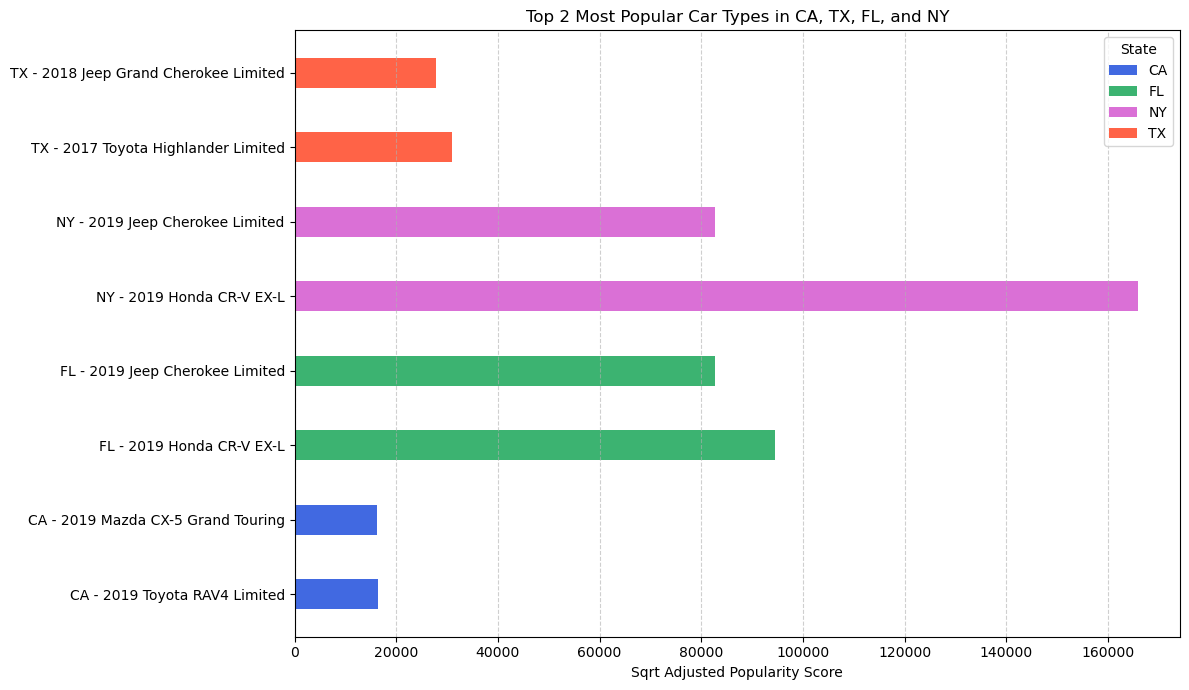

In [55]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load the dataset
file_path = 'Online_Cars_Sale_Marketplace.csv'
df = pd.read_csv(file_path)

# Step 2: Define target states
states_to_compare = ['CA', 'TX', 'FL', 'NY']
df_states = df[df['State'].isin(states_to_compare)]

# Step 3: Group by State, Year, Make, Model
grouped_states = df_states.groupby(['State', 'Year', 'Make', 'Model']).agg({
    'ConsumerRating': 'mean',
    'ConsumerReviews': 'sum',
    'VIN': 'count'  # number of listings
}).reset_index()

# Step 4: Rename VIN to Listings
grouped_states = grouped_states.rename(columns={'VIN': 'Listings'})

# Step 5: Calculate Sqrt Adjusted Popularity Score
grouped_states['SqrtListings'] = np.sqrt(grouped_states['Listings'])
grouped_states['SqrtAdjustedPopularity'] = (
    grouped_states['ConsumerRating'] *
    grouped_states['ConsumerReviews'] *
    grouped_states['SqrtListings']
)

# Step 6: Get top 2 car types per state
top2_by_state = grouped_states.sort_values(by=['State', 'SqrtAdjustedPopularity'], ascending=[True, False]) \
                              .groupby('State').head(2).copy()

# ✅ Step 7: Include state in label to avoid overlap
top2_by_state['CarLabel'] = (
    top2_by_state['State'] + ' - ' +
    top2_by_state['Year'].astype(str) + ' ' +
    top2_by_state['Make'] + ' ' +
    top2_by_state['Model']
)

# Step 8: Plot all top 2 cars on one horizontal bar chart
plt.figure(figsize=(12, 7))

# Define custom colors per state
colors = {
    'CA': 'royalblue',
    'TX': 'tomato',
    'FL': 'mediumseagreen',
    'NY': 'orchid'
}

# Set reduced bar height
bar_height = 0.4

# Plot each bar
for index, row in top2_by_state.iterrows():
    plt.barh(row['CarLabel'], row['SqrtAdjustedPopularity'], 
             color=colors.get(row['State'], 'gray'), 
             height=bar_height, 
             label=row['State'])

# Clean up duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title='State')

# Final styling
plt.xlabel('Sqrt Adjusted Popularity Score')
plt.title('Top 2 Most Popular Car Types in CA, TX, FL, and NY')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


<>:17: SyntaxWarning: invalid escape sequence '\$'
<>:17: SyntaxWarning: invalid escape sequence '\$'
C:\Users\patron\AppData\Local\Temp\ipykernel_32192\3270161088.py:17: SyntaxWarning: invalid escape sequence '\$'
  .replace({'\$': '', ',': ''}, regex=True)


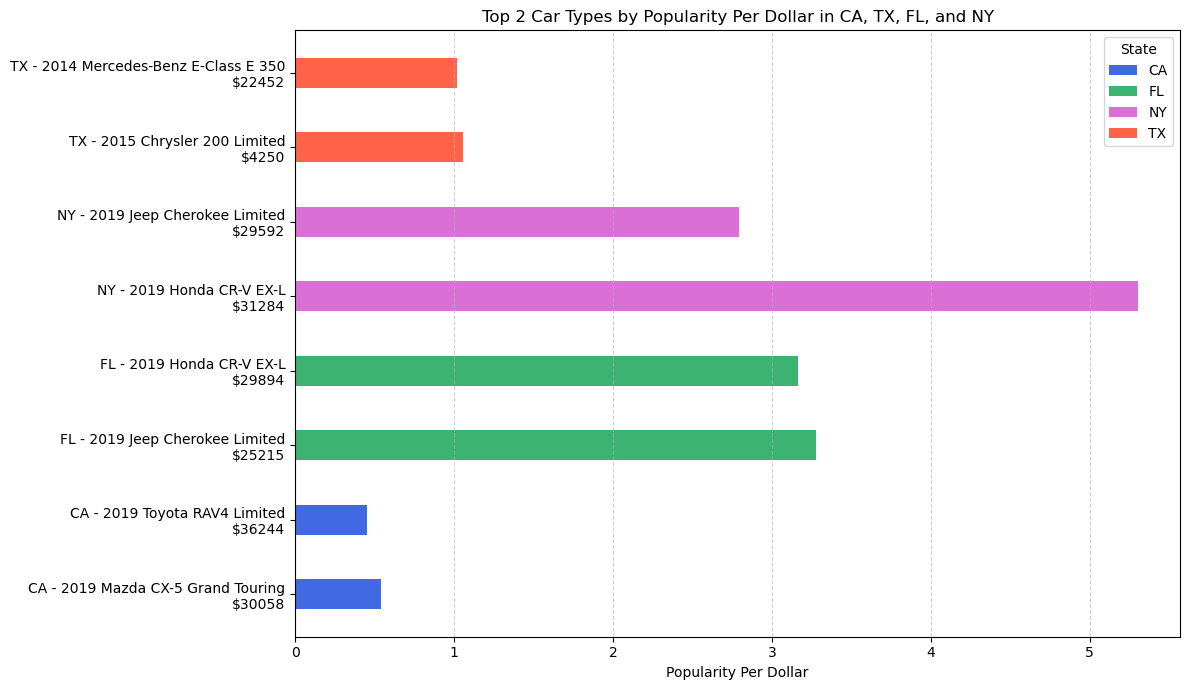

In [56]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
file_path = 'Online_Cars_Sale_Marketplace.csv'
df = pd.read_csv(file_path)

# Step 1: Filter for selected states
states_to_compare = ['CA', 'TX', 'FL', 'NY']
df_states = df[df['State'].isin(states_to_compare)].copy()

# Step 2: Clean the 'Price' column
df_states['Price'] = (
    df_states['Price']
    .replace({'\$': '', ',': ''}, regex=True)
    .replace('Not Priced', np.nan)
)
df_states['Price'] = pd.to_numeric(df_states['Price'], errors='coerce')

# Step 3: Group by State, Year, Make, Model and compute aggregates
grouped_value_states = df_states.groupby(['State', 'Year', 'Make', 'Model']).agg({
    'ConsumerRating': 'mean',
    'ConsumerReviews': 'sum',
    'Price': 'mean',
    'VIN': 'count'
}).reset_index()

# Step 4: Compute popularity and value metrics
grouped_value_states = grouped_value_states.rename(columns={'VIN': 'Listings'})
grouped_value_states['SqrtListings'] = np.sqrt(grouped_value_states['Listings'])
grouped_value_states['SqrtAdjustedPopularity'] = (
    grouped_value_states['ConsumerRating'] *
    grouped_value_states['ConsumerReviews'] *
    grouped_value_states['SqrtListings']
)
grouped_value_states['PopularityPerDollar'] = (
    grouped_value_states['SqrtAdjustedPopularity'] / grouped_value_states['Price']
)

# Step 5: Remove invalid rows
filtered_states_value = grouped_value_states.dropna(subset=['PopularityPerDollar'])
filtered_states_value = filtered_states_value[
    filtered_states_value['PopularityPerDollar'].replace([np.inf, -np.inf], np.nan).notnull()
]

# Step 6: Select top 2 value cars per state
top2_value_by_state = filtered_states_value.sort_values(
    by=['State', 'PopularityPerDollar'], ascending=[True, False]
).groupby('State').head(2).copy()

# Step 7: Add readable car labels with price
top2_value_by_state['CarLabel'] = (
    top2_value_by_state['State'] + ' - ' +
    top2_value_by_state['Year'].astype(str) + ' ' +
    top2_value_by_state['Make'] + ' ' +
    top2_value_by_state['Model']
)
top2_value_by_state['BarLabel'] = (
    top2_value_by_state['CarLabel'] + '\n$' +
    top2_value_by_state['Price'].round(0).astype(int).astype(str)
)

# Step 8: Plot horizontal bar chart
plt.figure(figsize=(12, 7))

# Define custom colors for each state
colors = {
    'CA': 'royalblue',
    'TX': 'tomato',
    'FL': 'mediumseagreen',
    'NY': 'orchid'
}

for index, row in top2_value_by_state.iterrows():
    plt.barh(row['BarLabel'], row['PopularityPerDollar'],
             color=colors.get(row['State'], 'gray'),
             height=0.4,
             label=row['State'])

# Avoid duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title='State')

# Final formatting
plt.xlabel('Popularity Per Dollar')
plt.title('Top 2 Car Types by Popularity Per Dollar in CA, TX, FL, and NY')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


<>:16: SyntaxWarning: invalid escape sequence '\$'
<>:16: SyntaxWarning: invalid escape sequence '\$'
C:\Users\patron\AppData\Local\Temp\ipykernel_32192\659723771.py:16: SyntaxWarning: invalid escape sequence '\$'
  .replace({'\$': '', ',': ''}, regex=True)


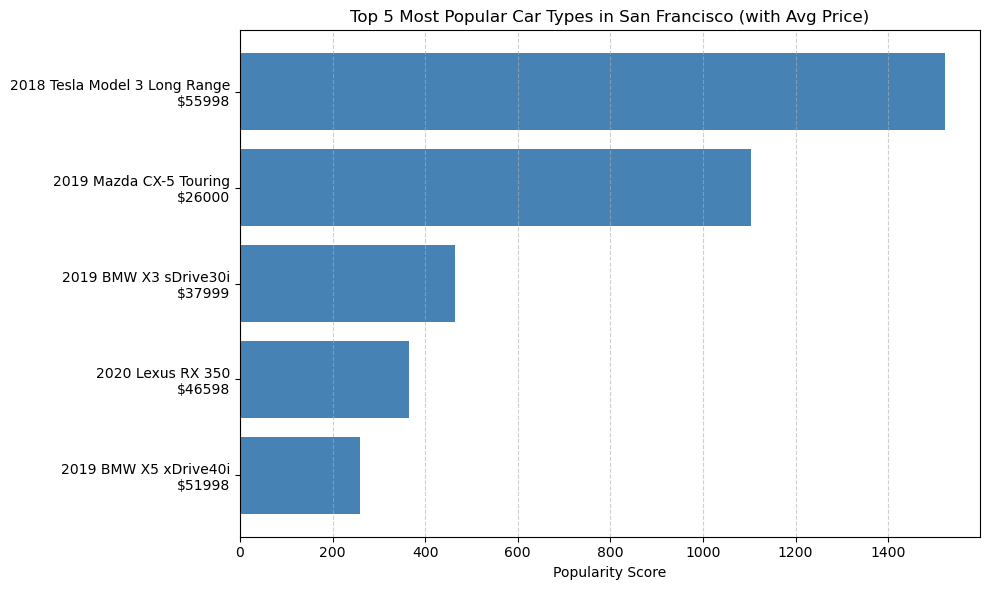

In [61]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
file_path = 'Online_Cars_Sale_Marketplace.csv'
df = pd.read_csv(file_path)

# Filter for San Francisco zip codes (starting with '941')
df_sf = df[df['Zipcode'].astype(str).str.startswith('941')].copy()

# Clean the 'Price' column
df_sf['Price'] = (
    df_sf['Price']
    .replace({'\$': '', ',': ''}, regex=True)
    .replace('Not Priced', np.nan)
)
df_sf['Price'] = pd.to_numeric(df_sf['Price'], errors='coerce')

# Group by car type and compute metrics including price
grouped_sf_popularity_price = df_sf.groupby(['Year', 'Make', 'Model']).agg({
    'ConsumerRating': 'mean',
    'ConsumerReviews': 'sum',
    'Price': 'mean',
    'VIN': 'count'  # number of listings
}).reset_index()

# Compute popularity score
grouped_sf_popularity_price = grouped_sf_popularity_price.rename(columns={'VIN': 'Listings'})
grouped_sf_popularity_price['SqrtListings'] = np.sqrt(grouped_sf_popularity_price['Listings'])
grouped_sf_popularity_price['PopularityScore'] = (
    grouped_sf_popularity_price['ConsumerRating'] *
    grouped_sf_popularity_price['ConsumerReviews'] *
    grouped_sf_popularity_price['SqrtListings']
)

# Sort and select top 5 by popularity score
top5_popular_sf_price = grouped_sf_popularity_price.sort_values(by='PopularityScore', ascending=False).head(5).copy()
top5_popular_sf_price['CarLabel'] = (
    top5_popular_sf_price['Year'].astype(str) + ' ' +
    top5_popular_sf_price['Make'] + ' ' +
    top5_popular_sf_price['Model']
)
top5_popular_sf_price['BarLabel'] = (
    top5_popular_sf_price['CarLabel'] + '\n$' + top5_popular_sf_price['Price'].round(0).astype(int).astype(str)
)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top5_popular_sf_price['BarLabel'], top5_popular_sf_price['PopularityScore'], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('Popularity Score')
plt.title('Top 5 Most Popular Car Types in San Francisco (with Avg Price)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


<>:16: SyntaxWarning: invalid escape sequence '\$'
<>:16: SyntaxWarning: invalid escape sequence '\$'
C:\Users\patron\AppData\Local\Temp\ipykernel_32192\4077218061.py:16: SyntaxWarning: invalid escape sequence '\$'
  .replace({'\$': '', ',': ''}, regex=True)


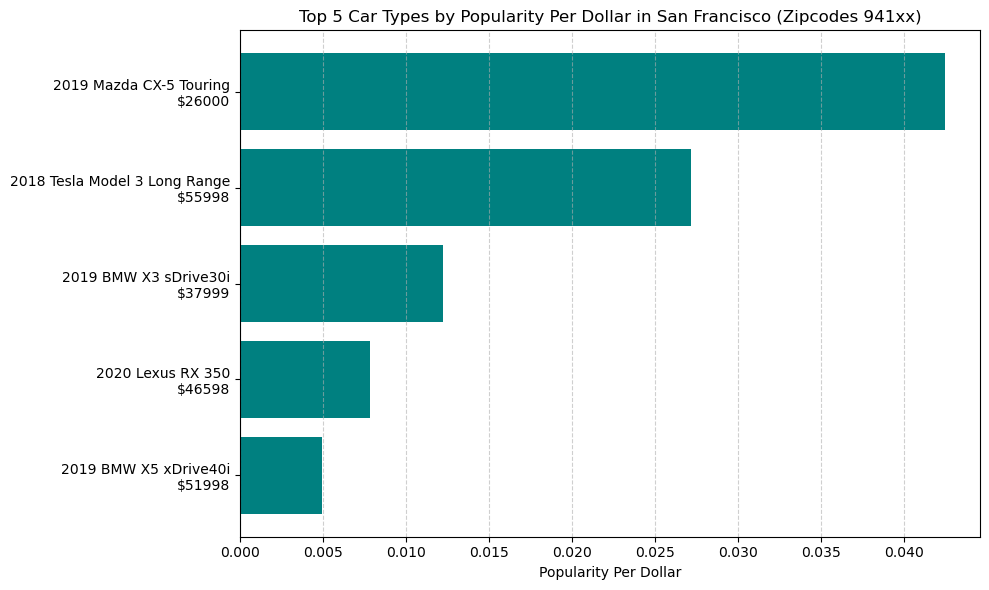

In [63]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
file_path = 'Online_Cars_Sale_Marketplace.csv'
df = pd.read_csv(file_path)

# Filter for San Francisco zip codes (starting with '941')
df_sf = df[df['Zipcode'].astype(str).str.startswith('941')].copy()

# Clean the 'Price' column
df_sf['Price'] = (
    df_sf['Price']
    .replace({'\$': '', ',': ''}, regex=True)
    .replace('Not Priced', np.nan)
)
df_sf['Price'] = pd.to_numeric(df_sf['Price'], errors='coerce')

# Group by car type and compute metrics
grouped_sf_value = df_sf.groupby(['Year', 'Make', 'Model']).agg({
    'ConsumerRating': 'mean',
    'ConsumerReviews': 'sum',
    'Price': 'mean',
    'VIN': 'count'
}).reset_index()

# Compute scores
grouped_sf_value = grouped_sf_value.rename(columns={'VIN': 'Listings'})
grouped_sf_value['SqrtListings'] = np.sqrt(grouped_sf_value['Listings'])
grouped_sf_value['SqrtAdjustedPopularity'] = (
    grouped_sf_value['ConsumerRating'] *
    grouped_sf_value['ConsumerReviews'] *
    grouped_sf_value['SqrtListings']
)
grouped_sf_value['PopularityPerDollar'] = (
    grouped_sf_value['SqrtAdjustedPopularity'] / grouped_sf_value['Price']
)

# Remove invalid rows
filtered_sf = grouped_sf_value.dropna(subset=['PopularityPerDollar'])
filtered_sf = filtered_sf[filtered_sf['PopularityPerDollar'].replace([np.inf, -np.inf], np.nan).notnull()]

# Get top 5 by Popularity Per Dollar
top5_value_sf = filtered_sf.sort_values(by='PopularityPerDollar', ascending=False).head(5).copy()
top5_value_sf['CarLabel'] = (
    top5_value_sf['Year'].astype(str) + ' ' +
    top5_value_sf['Make'] + ' ' +
    top5_value_sf['Model']
)
top5_value_sf['BarLabel'] = (
    top5_value_sf['CarLabel'] + '\n$' + top5_value_sf['Price'].round(0).astype(int).astype(str)
)

# Plot the result
plt.figure(figsize=(10, 6))
plt.barh(top5_value_sf['BarLabel'], top5_value_sf['PopularityPerDollar'], color='teal')
plt.gca().invert_yaxis()
plt.xlabel('Popularity Per Dollar')
plt.title('Top 5 Car Types by Popularity Per Dollar in San Francisco (Zipcodes 941xx)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
